# Chebyshev Nodes vs Uniform Nodes for Interpolation

Uniform interpolation can exhibit Runge oscillations for rational-like functions.
We compare interpolation of
$$
f(x)=\frac{1}{\kappa^2+x^2}
$$
using uniform nodes and Chebyshev nodes.

Polynomial interpolation error depends as much on node placement as on degree. Uniform grids can amplify endpoint oscillations, whereas Chebyshev nodes cluster where the interpolation problem is most ill-conditioned. The experiments compare errors and Lebesgue amplification to explain why minimax-oriented sampling is stable.

Tracking the error over degree reveals not only which grid wins, but when endpoint instability begins to dominate additional polynomial resolution.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

import ipywidgets as widgets
kappa = 0.15
f = lambda x: 1.0 / (kappa**2 + x**2)
xg = np.linspace(-1, 1, 1000)
yg = f(xg)


## Chebyshev polynomial on [-1,1]


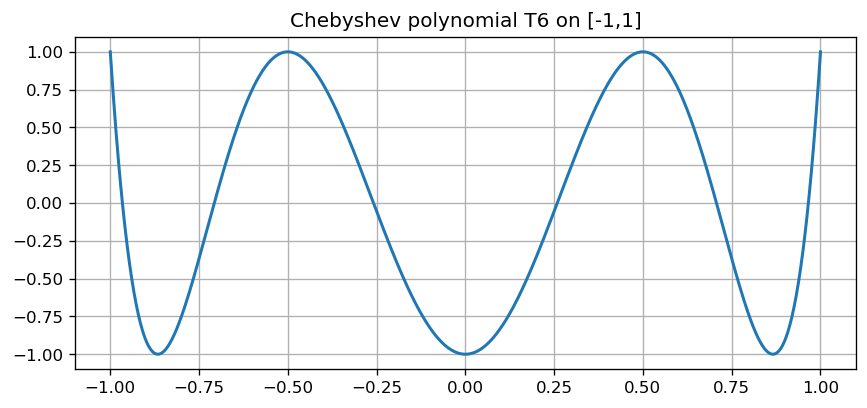

In [2]:
T6 = np.cos(6*np.arccos(np.clip(xg, -1, 1)))
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.plot(xg, T6, lw=1.8)
ax.set_title('Chebyshev polynomial T6 on [-1,1]')
plt.show()


## Small / medium / large interpolation sizes


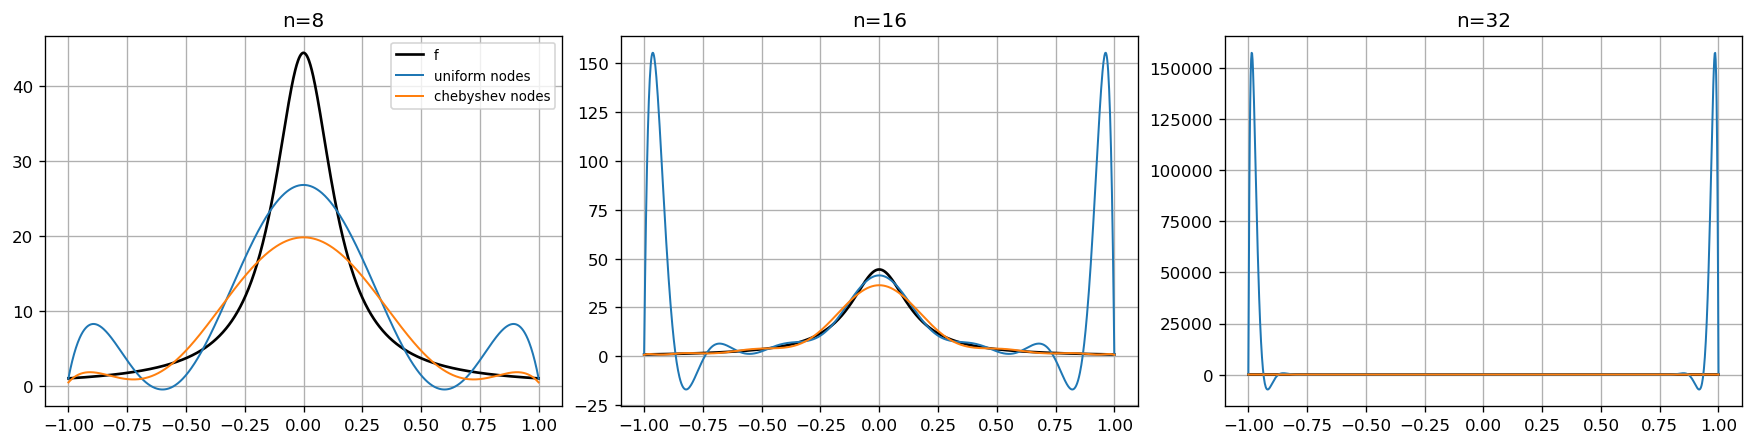

In [3]:
sizes = [8, 16, 32]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6), constrained_layout=True)
for ax, n in zip(axes, sizes):
    xu = np.linspace(-1, 1, n)
    xc = np.cos((2*np.arange(n)+1)/(2*n)*np.pi)
    pu = np.poly1d(np.polyfit(xu, f(xu), n-1))
    pc = np.poly1d(np.polyfit(xc, f(xc), n-1))
    ax.plot(xg, yg, 'k', lw=1.6, label='f')
    ax.plot(xg, pu(xg), lw=1.2, label='uniform nodes')
    ax.plot(xg, pc(xg), lw=1.2, label='chebyshev nodes')
    ax.set_title(f'n={n}')
axes[0].legend(fontsize=8)
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive slider: node count and node type


## Bibliographical resources

- Trefethen, L. N. (2013). *Approximation Theory and Approximation Practice*. SIAM.
- Berrut, J.-P. and Trefethen, L. N. (2004). Barycentric Lagrange interpolation. *SIAM Review*, 46, 501--517.
- Cheney, E. W. (1982). *Introduction to Approximation Theory*. AMS Chelsea.